
# Analytics of the Rossler system
---

## Introduction

The Rossler equations are a set of differential equations which ehibit chaotic behaviour as a result of non-linear terms. They were developed as a potential simplification to the Lorenz equations and are given by:
$$$$
 $$ẋ = -y -z$$ $$ẏ = x + ay $$ $$ż = b + z(x-c)$$
$$$$
How the system behaves is highly dependent on the values of the coefficients a,b and c. For certain combinations, the system does show periodic orbits or limit cycles for a while but, after a certain point, this breaks down into the filling of the phase space and unpredictable behaviour. The following document aims to explore the limits of what can be done analytically to gain information about the nature of said coefficients.

## Fixed Points

As always with a non-linear system, one should start with the finding of the fixed points. Setting each derivative to 0 respectively, from the first equation, we find $y=-z$ and, from the second one $\frac{-x}{a} = y$. If we now look at the third equation,and substitute these two results into it, we get: $$ ay^2 +cy +b = 0$$ It's now possible to apply the quadratic formula to find that: $$y = \frac{-c ± \sqrt{c^2 - 4ab}}{2a} $$ Only two observations remain to find the fixed points after this. Firstly, the fact that, based on this value of y, one can find values for x and z too because of the relationship between them and, secondly, that the Rossler equations are symmetric, so the opposite sign version of any fixed point will also be a fixed point. This leads to the result that the fixed points are at:
$$$$
 $$ (\frac{c + \sqrt{c^2 - 4ab}}{2}, \frac{-c - \sqrt{c^2 - 4ab}}{2a}, \frac{c + \sqrt{c^2 - 4ab}}{2a})$$
$$$$
$$And$$
$$$$
$$(\frac{c - \sqrt{c^2 - 4ab}}{2}, \frac{-c + \sqrt{c^2 - 4ab}}{2a}, \frac{c - \sqrt{c^2 - 4ab}}{2a})$$

As a result of the square root in each of above coordinates, we already get an example of a saddle-node bifurcation at the point $ c^2 = 4ab$. If $c^2 < 4ab$, the coordinates become complex, meaning the fixed points annihilate each other and we get a system that is drastically different from the one with 2 fixed points for $c^2 > 4ab $.

## Nature of fixed points

It's possible to continue the analysis by examining the nature of the fixed points next. To start, the Jacobian of the system at the fixed points is computed, with $(x_F,y_F,z_F)$ signifying each of the respective fixed point coordinates:
$$ A(x_F,y_F,z_F) = \begin{bmatrix}0 & 1 & -1\\ 1 & a & 0 \\ z_F & 0 & x_F-c
\end{bmatrix}$$
Next, one can calculate the eigenvalues, $λ$, of the system by using the characteristic equation:
$$$$
$$ \left\lvert \begin{matrix} -λ & 1& -1 \\ 1 & a-λ & 0 \\ z_F & 0 & x_F-c-λ
\end{matrix}\right\rvert = λ^3 -λ^2 (a+x_F-c) - λ(ac-a x_F -1 - z_F) - (x_f -c) -a z_F$$
$$$$
The nature of the fixed points now depends on the value of $λ$ one gets from solving this cubic equation, however, this is in turn dependent on the chosen value of the coefficients $a,b,$ and $c$. Therefore, for the Rossler system, two of these coefficients are often given a specific value whilst the third one is varied. Most commonly, the choices are to vary $c$ and have $a=b=0.2$


## Varying c

The equations, even with these imposed values, still won't be solved though, as,for analysis, it's enough to know whether three eigenvalues will be real or only one will be real and the two others a complex conjugate pair. For the Rossleer system to exhibit chaotic behaviour , the latter regime must be chosen, and this has been done implicitly by choosing a small value of a. (The condition for all real eigenvalues would be $a^2 - 4 >0$)
$$$$

So, now what matters is if the real parts of the two complex values are positive - as this changes the nature of the fixed points. To gain an understanding about this, one has to use the **Ruth-Hurwitz criterion** to infer what the real parts of the eigenvalues could be. The necessary part of the Routh-Hurwitz criterion for this system, states that for an equation, $$ λ^3 + A_1 λ^2 + A_2 λ + A_3 = 0$$ the eigenvalues have negative real parts if the following conditions are satisfied:
$$ A_1,A_2,A_3 > 0$$
$$And$$
$$A_1A_2 > A_3$$
For the given regime we have set up in the Rossler system, as long as $c< 4$, all the above conditions are satisfied and so we get a **stable focus** at the fixed point. It is at around $c≈4$ however, that the last condition starts to be violated which leads to a **Hopf bifurcation** at $A_1A_2 = A_3$

## The Hopf Bifurcation

This bifurcation point is especially important as it marks the beginning of what will be the chaos in the sysyem. At this point, the real part of the complex eigenvalues will be 0, such that $λ_{2,3} = ± i ω$ and so a limit cycle with frequency $ω$ will develop in the system. The rotational nature at the base of the Rossler system is as a result of this limit cycle.
$$$$
To get further information about the system, numerical methods must be used. As $c$ increases, the values of coefficients to the eigenvalues must be calculated each time to be able to describe the system meaningfully. Much of this work is shown below via codes and bifurcation diagrams. A final thing that is perhaps important to note is that, for these parameters, chaos in the system fully develops around $c ≈ 5.7 $ and so, any predictions beyond this are very difficult to make.

Text(0.5, 0.92, 'RK4: Rössler')

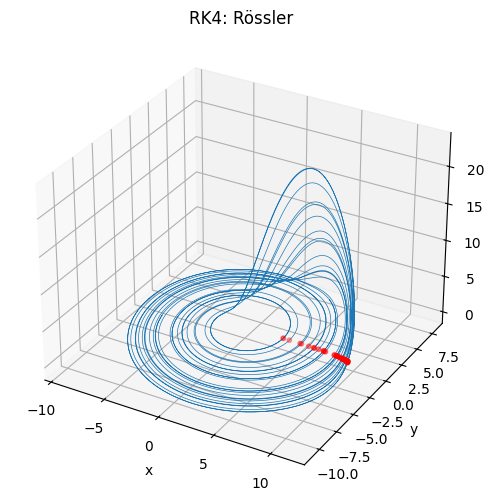

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from numpy.linalg import eigvals
from scipy.signal import find_peaks
## all done using RK4

# Parameters (classic chaotic regime)
a = 0.2
b = 0.2
c = 5.7

# Rössler system
def rossler(t, X):
    x, y, z = X
    dxdt = -y - z
    dydt = x + a*y
    dzdt = b + z*(x - c)
    return [dxdt, dydt, dzdt]

# Time span
t_span = (0, 300)
t_eval = np.linspace(0, 300, 50000)

# Solve ODE
sol = solve_ivp(rossler, t_span, [1, 1, 1], t_eval=t_eval)

x = sol.y[0]
y = sol.y[1]
z = sol.y[2]

# Remove transient (first half)
cut = len(t_eval) // 2
x = x[cut:]
y = y[cut:]
z = z[cut:]

# Find maxima of x, one peak per loop
peaks, _ = find_peaks(x, distance=50)

# 3D Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(projection='3d')

ax.plot(x, y, z, linewidth=0.5)

# Mark maximal x points
ax.scatter(x[peaks], y[peaks], z[peaks], color='red', s=10)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("RK4: Rössler")


CPU times: user 42.8 ms, sys: 1.72 ms, total: 44.5 ms
Wall time: 133 ms


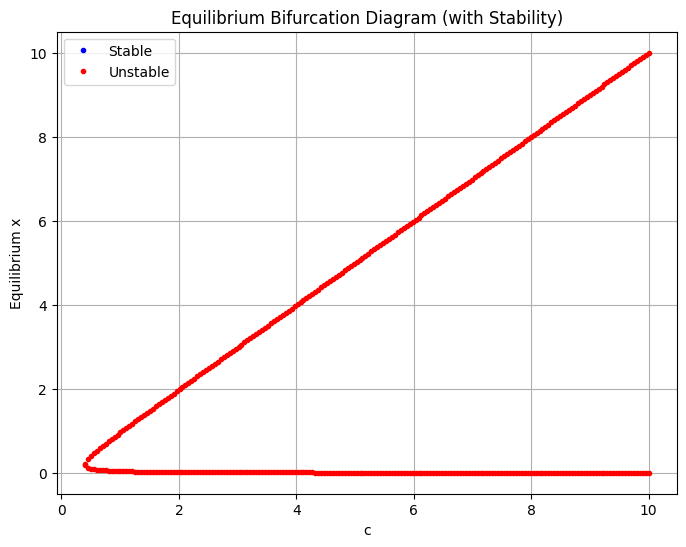

In [2]:
%%time
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from numpy.linalg import eigvals
# Equilibrium Rossler bifurcation diagram, a and b fixed

a = 0.2
b = 0.2

c_vals = np.linspace(0, 10, 200)

stable_x = []
unstable_x = []
stable_c = []
unstable_c = []

for c in c_vals:

    discriminant = c**2 - 4*a*b

    if discriminant >= 0:
        z_vals = [
            (c + np.sqrt(discriminant)) / (2*a),
            (c - np.sqrt(discriminant)) / (2*a)
        ]

        for z in z_vals:
            x = a * z
            y = -z

            # Jacobian
            J = np.array([
                [0, -1, -1],
                [1, a, 0],
                [z, 0, x - c]
            ])

            eigs = eigvals(J)

            if np.all(np.real(eigs) < 0):
                stable_c.append(c)
                stable_x.append(x)
            else:
                unstable_c.append(c)
                unstable_x.append(x)

plt.figure(figsize=(8,6))

plt.plot(stable_c, stable_x, 'b.', label='Stable')
plt.plot(unstable_c, unstable_x, 'r.', label='Unstable')

plt.xlabel("c")
plt.ylabel("Equilibrium x")
plt.title("Equilibrium Bifurcation Diagram (with Stability)")
plt.legend()
plt.grid(True)


CPU times: user 4min 53s, sys: 459 ms, total: 4min 53s
Wall time: 4min 57s


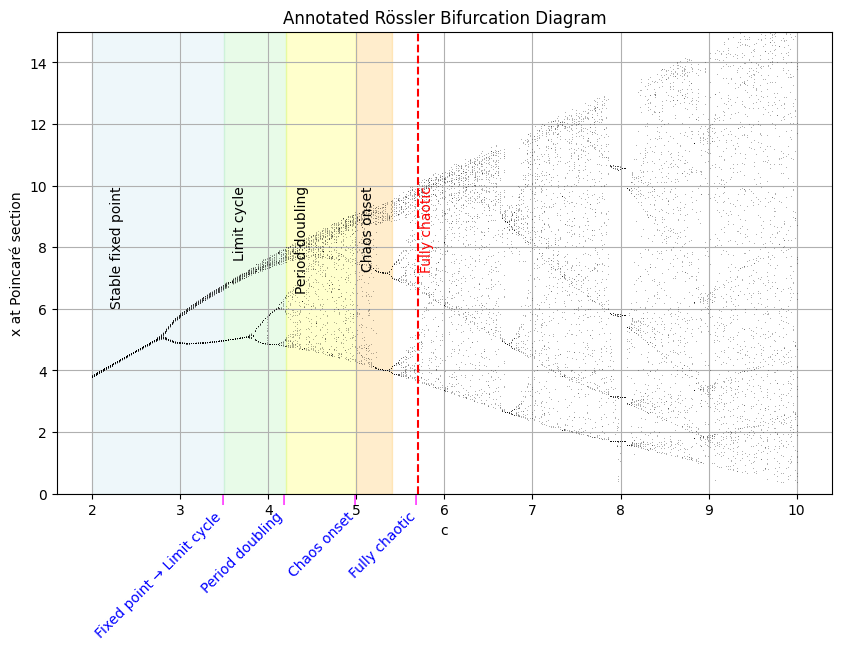

In [ ]:
%%time

# Discrete Rossler bifurcation diagram, a and b fixed

# Rössler parameters
a, b = 0.2, 0.2

def rossler(t, X, c):
    x, y, z = X
    return [-y - z,
            x + a*y,
            b + z*(x - c)]

c_vals = np.linspace(2, 10, 400)

plt.figure(figsize=(10,6))

for c in c_vals:
    sol = solve_ivp(rossler, [0, 400], [1,1,1],
                    args=(c,),
                    max_step=0.05)

    x, y = sol.y[0], sol.y[1]

    # Removing the transient
    # ensures you're plotting only the chaotic attractor values
    #A Bifurcation diagram shows the long-term
    #states of the system as a parameter changes.
    #So we must remove the part where the system is still relaxing to equilibrium.

    x = x[sol.t > 200]
    y = y[sol.t > 200]

    # Detect crossings y=0 upward (Poincaré section)
    crossings = []
    for i in range(len(y)-1):
        if y[i] < 0 and y[i+1] > 0 and x[i] > 0:
            crossings.append(x[i])

    if crossings:
        plt.plot([c]*len(crossings), crossings, ',k', alpha=0.3)

plt.axvspan(2, 3.5, color='lightblue', alpha=0.2)
plt.text(2.2, 10, 'Stable fixed point', rotation=90, va='top')

plt.axvspan(3.5, 4.2, color='lightgreen', alpha=0.2)
plt.text(3.6, 10, 'Limit cycle', rotation=90, va='top')

plt.axvspan(4.2, 5.0, color='yellow', alpha=0.2)
plt.text(4.3, 10, 'Period doubling', rotation=90, va='top')

plt.axvspan(5.0, 5.4, color='orange', alpha=0.2)
plt.text(5.05, 10, 'Chaos onset', rotation=90, va='top')

plt.axvline(5.7, color='red', linestyle='--', linewidth=1.5)
plt.text(5.72, 10, 'Fully chaotic', rotation=90, va='top', color='red')

plt.xlabel("c")
plt.ylabel("x at Poincaré section") # the x values where it intercepts the poincare section that we chose.
plt.title("Annotated Rössler Bifurcation Diagram")
plt.ylim(0, 15)
plt.grid(True)

rough_points = {
    3.5: 'Fixed point → Limit cycle',
    4.2: 'Period doubling',
    5.0: 'Chaos onset',
    5.7: 'Fully chaotic'
}

for x, label in rough_points.items():
    plt.text(x, -0.5, label,rotation=45, ha='right', va='top', fontsize=10, color='blue')

roughpoints = {
    3.5: 'I',
    4.2: 'I',
    5.0: 'I',
    5.7: 'I'
}

for x, label in roughpoints.items():
    plt.text(x, 0, label, ha='right', va='top', fontsize=10, color='magenta')